# Problem 1: Particle Filter for a Nonlinear System

You are asked to implement a particle filter for the following nonlinear system:

$$
\mathbf{x}_k =
\begin{bmatrix}
x_{k+1} \\
y_{k+1} \\
\theta_{k+1}
\end{bmatrix}
=
\begin{bmatrix}
x_k + \cos \theta_k \\
y_k + \sin \theta_k \\
\theta_k
\end{bmatrix}
$$

## Initial State and Covariance

The initial state estimate is:

$$
\mathbf{x}_0 =
\begin{bmatrix}
0 \\
0 \\
0
\end{bmatrix}
$$

The initial covariance matrix is:

$$
\mathbf{P}_0 =
\begin{bmatrix}
0.01 & 0 & 0 \\
0 & 0.01 & 0 \\
0 & 0 & 10000
\end{bmatrix}
$$

For the initial guess, generate randomly distributed particles around the above-given initial condition.

Use **100 or more particles** and observe how the performance of the particle filter changes as the number of particles increases.




## Part (a): Prediction Step Only

Implement a particle filter and run its **prediction step** with **no measurement update**.

Compute the result and plot it.



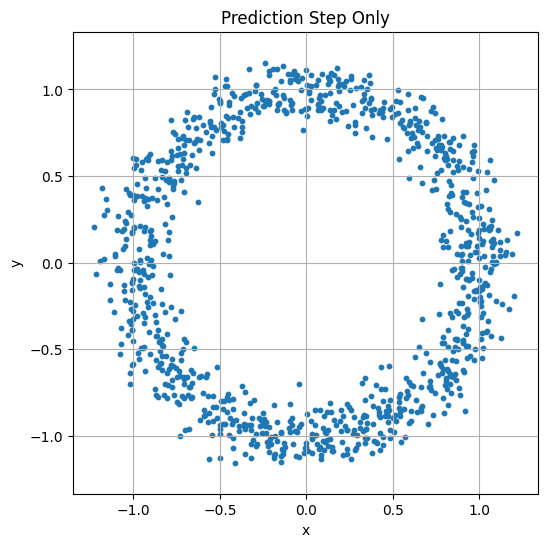

In [11]:
import numpy as np
import matplotlib.pyplot as plt


def wrap_angle(angle):
    return (angle + np.pi) % (2 * np.pi) - np.pi


x0 = np.array([0, 0, 0])   # [x, y, theta]

P0 = np.array([
    [0.01, 0,    0],
    [0,    0.01, 0],
    [0,    0,    10000]
])

N = 1000   


particles = np.random.multivariate_normal(x0, P0, N)
particles[:, 2] = wrap_angle(particles[:, 2])

particles_pred = particles.copy()
particles_pred[:, 0] = particles[:, 0] + np.cos(particles[:, 2])
particles_pred[:, 1] = particles[:, 1] + np.sin(particles[:, 2])
particles_pred[:, 2] = particles[:, 2]


plt.figure(figsize=(6, 6))
plt.scatter(particles_pred[:, 0], particles_pred[:, 1], s=10)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Prediction Step Only")
plt.axis("equal")
plt.grid(True)
plt.show()

## Part (b): Measurement Update

Now add a measurement to the estimate:

$$
\mathbf{z}_k = \mathbf{x}_k + \mathbf{v}_k
$$

The measurement noise is:

$$
\mathbf{v}_k \sim N(0, R\mathbf{I})
$$

where:

$$
R = 0.01
$$

Compute the result and plot it.

Compare this result with your intuition about particle filters.

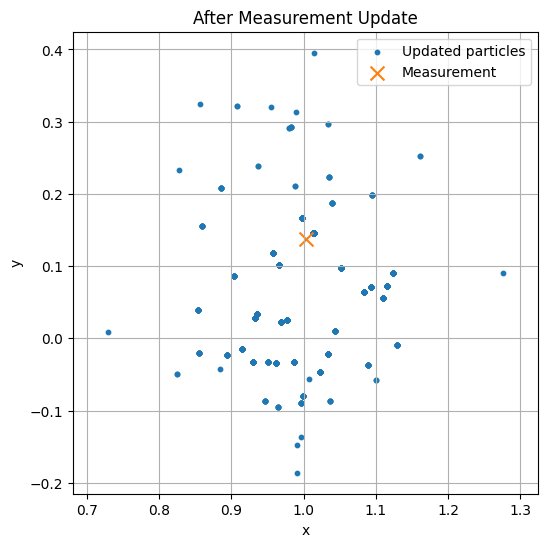

In [6]:
R = 0.01
measurement_cov = R * np.eye(3)

true_state = np.array([1, 0, 0])

# Simulated measurement
z = true_state + np.random.multivariate_normal(np.zeros(3), measurement_cov)
z[2] = wrap_angle(z[2])


weights = np.zeros(N)

for i in range(N):
    error = z - particles_pred[i]

    
    error[2] = wrap_angle(error[2])

    weights[i] = np.exp(-0.5 * error.T @ np.linalg.inv(measurement_cov) @ error)

weights = weights / np.sum(weights)


indices = np.random.choice(np.arange(N), size=N, replace=True, p=weights)
particles_update = particles_pred[indices]

plt.figure(figsize=(6, 6))
plt.scatter(particles_update[:, 0], particles_update[:, 1], s=10, label="Updated particles")
plt.scatter(z[0], z[1], s=100, marker="x", label="Measurement")
plt.xlabel("x")
plt.ylabel("y")
plt.title("After Measurement Update")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()